# Email Spam Classification

## Importing the libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Data Preprocessing

### About the Dataset:
* Instances: 4601
* Features: 57
* Label: 'class', binary,  spam (1) or not (0)
* Missing Values: None

> Hopkins, M., Reeber, E., Forman, G., & Suermondt, J. (1999). Spambase [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C53G6X.


### Importing the dataset

In [2]:
df = pd.read_csv('spambase_csv.csv')
print(f'Length: {df.shape}')
print(f'Null: {df.isna().sum().sum()}')
print(f'Duplicated: {df.duplicated().sum()}')
print(f'Split: {df.value_counts('class', normalize=True)}')

Length: (4601, 58)
Null: 0
Duplicated: 391
Split: class
0    0.605955
1    0.394045
Name: proportion, dtype: float64


In [3]:
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

In [4]:
print(f'X shape: {X.shape}\n')
print(X)

X shape: (4601, 57)

[[0.000e+00 6.400e-01 6.400e-01 ... 3.756e+00 6.100e+01 2.780e+02]
 [2.100e-01 2.800e-01 5.000e-01 ... 5.114e+00 1.010e+02 1.028e+03]
 [6.000e-02 0.000e+00 7.100e-01 ... 9.821e+00 4.850e+02 2.259e+03]
 ...
 [3.000e-01 0.000e+00 3.000e-01 ... 1.404e+00 6.000e+00 1.180e+02]
 [9.600e-01 0.000e+00 0.000e+00 ... 1.147e+00 5.000e+00 7.800e+01]
 [0.000e+00 0.000e+00 6.500e-01 ... 1.250e+00 5.000e+00 4.000e+01]]


In [5]:
print(f'y shape: {y.shape}\n')
print(y)

y shape: (4601,)

[1 1 1 ... 0 0 0]


### Understanding the Dataset



> Spam - Not Spam split: 0.394045 - 0.605955. Baseline ~ 0.6060.
    
> Duplicates not dropped, duplicate row doesn't necessarily mean duplicate emails as the numbers are rounded percents of word occurrences and duplicates may occur.

> No missing values verified, no imputing or dropping needed.



### Splitting the dataset into the Training set and Test set

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 74)

In [7]:
print(f'X_train shape: {X_train.shape}\n')
print(X_train)

X_train shape: (3680, 57)

[[0.000e+00 0.000e+00 3.200e-01 ... 1.688e+00 1.900e+01 1.570e+02]
 [9.500e-01 0.000e+00 4.700e-01 ... 9.640e+00 2.590e+02 7.230e+02]
 [4.800e-01 2.000e-01 5.500e-01 ... 3.401e+00 9.400e+01 9.660e+02]
 ...
 [0.000e+00 0.000e+00 0.000e+00 ... 2.125e+00 1.200e+01 6.800e+01]
 [0.000e+00 0.000e+00 0.000e+00 ... 2.333e+00 1.100e+01 4.200e+01]
 [0.000e+00 0.000e+00 0.000e+00 ... 1.800e+01 2.000e+02 3.780e+02]]


In [8]:
print(f'X_test shape: {X_test.shape}\n')
print(X_test)

X_test shape: (921, 57)

[[0.000e+00 1.380e+00 1.380e+00 ... 2.052e+00 2.100e+01 3.900e+01]
 [4.000e-01 0.000e+00 0.000e+00 ... 1.194e+00 5.000e+00 1.290e+02]
 [0.000e+00 0.000e+00 0.000e+00 ... 1.000e+00 1.000e+00 7.000e+00]
 ...
 [0.000e+00 0.000e+00 5.300e-01 ... 5.038e+00 6.000e+01 1.310e+02]
 [0.000e+00 0.000e+00 0.000e+00 ... 2.588e+00 4.000e+01 1.320e+02]
 [1.180e+00 3.900e-01 5.900e-01 ... 6.652e+00 7.600e+01 6.320e+02]]


In [9]:
print(f'y_train shape: {y_train.shape}\n')
print(y_train)

y_train shape: (3680,)

[1 1 1 ... 0 0 0]


In [10]:
print(f'y_test shape: {y_test.shape}\n')
print(y_test)

y_test shape: (921,)

[0 1 0 0 0 0 0 0 0 0 0 1 1 1 1 0 1 0 0 1 0 0 1 0 0 0 0 0 1 0 0 1 0 0 0 0 1
 1 0 1 0 0 1 0 1 0 1 0 0 1 0 1 1 0 1 0 1 0 1 1 0 1 1 1 0 1 0 0 1 1 0 0 1 0
 1 1 1 1 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 1 0 1 1 1 1 0 0 0 0 0 1 0
 1 0 0 0 1 1 0 1 0 0 0 0 1 0 1 0 0 1 0 0 0 1 1 0 1 1 1 1 1 0 1 0 0 0 1 0 0
 0 0 0 1 0 1 0 0 0 0 1 1 0 0 1 0 0 1 0 1 0 0 0 0 1 0 0 0 1 0 0 1 0 0 1 0 1
 0 1 0 1 0 0 0 0 0 1 0 1 1 0 1 0 0 1 1 0 0 0 0 1 0 1 0 0 0 0 0 0 1 0 0 1 0
 1 0 0 1 0 1 0 0 0 0 0 0 1 0 1 0 0 0 1 1 1 1 0 0 0 0 1 1 0 1 0 0 1 1 0 1 0
 1 0 1 0 1 0 0 0 0 0 0 1 0 1 1 1 0 1 0 1 1 1 0 0 1 1 0 0 0 1 1 0 0 1 0 1 0
 0 0 0 1 0 1 0 0 1 0 0 0 1 1 0 1 0 0 1 1 1 0 0 1 0 0 1 1 0 0 0 0 1 0 1 0 1
 0 1 0 0 0 0 1 1 1 0 1 0 1 0 0 1 0 1 1 0 1 0 1 1 1 0 0 1 0 0 0 0 1 0 0 0 1
 1 1 0 0 0 1 0 1 0 1 0 1 0 0 1 0 0 0 1 1 1 1 0 0 0 1 1 1 1 0 0 0 0 0 0 1 0
 0 1 0 0 1 0 0 1 0 1 1 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 1 0 1 0 0 0 1 0 0 1
 0 1 0 0 1 1 0 0 1 1 0 1 0 1 0 1 1 0 0 0 0 1 1 0 0 1 0 0 1 0 0 0 1 0 1 0 0
 1 

## Fitting the Model - Logistic Regression

### Logistic Regression Before Feature Scaling

In [11]:
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression()
classifier.fit(X_train, y_train)

print(f'Train accuracy: {classifier.score(X_train, y_train):.4f}')
print(f'Test accuracy:  {classifier.score(X_test, y_test):.4f}')
print(f'n_iter_: {classifier.n_iter_}   (max_iter was {classifier.max_iter})')
print(f'Coefficients:\n  {classifier.coef_}')

Train accuracy: 0.9207
Test accuracy:  0.9251
n_iter_: [100]   (max_iter was 100)
Coefficients:
  [[-2.93931297e-02 -1.76742486e-01  1.67972896e-01  2.47091707e-01
   9.11407381e-01  4.09752781e-01  1.06348680e+00  7.13824246e-01
   2.56433687e-01  1.75818980e-01  1.87026105e-01 -1.46888590e-01
   7.56726871e-02  7.00483903e-02  2.26193199e-01  1.10409085e+00
   7.21842264e-01  4.91439854e-01  8.08418358e-02  4.90101794e-01
   3.33580356e-01  2.28638492e-01  9.11849445e-01  5.00118753e-01
  -2.59021225e+00 -1.27441589e+00 -3.49348004e+00 -2.28427036e-01
  -5.76361686e-01 -4.64577012e-01 -3.20820024e-01 -2.27251408e-01
  -6.32167471e-01 -2.31345160e-01 -5.67533882e-01 -1.19647320e-01
  -4.59597805e-01 -1.41968988e-01 -4.52765488e-01 -2.21107214e-01
  -3.78142415e-01 -9.39238530e-01 -2.76720909e-01 -5.42795502e-01
  -8.74878307e-01 -1.21684560e+00 -4.97761447e-02 -2.79657613e-01
  -4.34350375e-01 -2.09585177e-01 -9.46336182e-02  1.17229674e+00
   6.84857167e-01  1.17320805e-01 -1.2838028

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


#### Analyze Results

* The classifier took 100 iterations, not because it arrived at the minimum cost, but because it ran out of "budget", `max_iter`.

* Solutions: Increase the number of iterations `max_iter` or scale the data

### Solution 1 - Refit with more Iterations

In [12]:
classifier_more_iter = LogisticRegression(max_iter=4000)
classifier_more_iter.fit(X_train, y_train)

print(f'Train accuracy: {classifier_more_iter.score(X_train, y_train):.4f}')
print(f'Test accuracy:  {classifier_more_iter.score(X_test, y_test):.4f}')
print(f'n_iter_: {classifier_more_iter.n_iter_}   (max_iter was {classifier_more_iter.max_iter})')
print(f'Coefficients:\n  {classifier_more_iter.coef_}')

Train accuracy: 0.9356
Test accuracy:  0.9273
n_iter_: [3074]   (max_iter was 4000)
Coefficients:
  [[-3.40189136e-01 -1.26817579e-01  1.46766468e-01  8.24326947e-01
   7.11654777e-01  6.63766809e-01  1.93831808e+00  6.32027808e-01
   5.08764099e-01  1.04193345e-01 -4.15722687e-02 -1.35721685e-01
  -1.78092226e-01  1.50821194e-01  1.08966116e+00  9.53724802e-01
   9.88407554e-01  2.11895636e-01  7.91795111e-02  1.15704977e+00
   2.68709314e-01  2.74421124e-01  1.73529391e+00  5.02149585e-01
  -1.68464172e+00 -9.25172703e-01 -3.56580102e+00  4.57536273e-01
  -1.21472073e+00 -2.66198253e-01 -2.47718283e-01  9.05733468e-02
  -6.81002377e-01 -2.05599599e-01 -1.23829567e+00  9.83227179e-01
   9.18016028e-02 -4.30557499e-01 -9.26597122e-01 -2.59962893e-01
  -1.84497372e+00 -1.59988825e+00 -7.29046938e-01 -1.37198038e+00
  -5.77689566e-01 -1.30271486e+00 -5.76937394e-01 -1.61459028e+00
  -1.11290324e+00 -1.10180951e-01 -5.50770656e-01  1.09737415e+00
   4.10546483e+00  1.24093680e+00 -1.47202

### Solution 2 - Apply Feature Scaling

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [14]:
from sklearn.linear_model import LogisticRegression
classifier_scaled = LogisticRegression()
classifier_scaled.fit(X_train_scaled, y_train)

print(f'Train accuracy: {classifier_scaled.score(X_train_scaled, y_train):.4f}')
print(f'Test accuracy:  {classifier_scaled.score(X_test_scaled, y_test):.4f}')
print(f'n_iter_: {classifier_scaled.n_iter_}   (max_iter was {classifier_scaled.max_iter})')
print(f'Coefficients:\n  {classifier_scaled.coef_}')

Train accuracy: 0.9342
Test accuracy:  0.9305
n_iter_: [32]   (max_iter was 100)
Coefficients:
  [[-0.09845231 -0.16873246  0.06993508  0.86325116  0.45463175  0.15664956
   0.79351111  0.23175249  0.09896666  0.06434733 -0.00491708 -0.11853479
  -0.0821022   0.04031241  0.46559929  0.77118686  0.44824625  0.09577339
   0.14693277  0.58161634  0.29508694  0.2834542   0.68328098  0.19909743
  -2.41734482 -0.89939485 -4.10070521  0.28376397 -1.02432471 -0.12410355
  -0.41630895 -0.05675616 -0.39374479 -0.42599323 -1.12559903  0.40156735
   0.04302387 -0.11605132 -0.35111595 -0.13460424 -1.76448917 -1.33568908
  -0.239064   -0.84033674 -0.64968437 -1.12958805 -0.1282901  -0.72302526
  -0.33843518 -0.04466749 -0.1717941   0.72165255  1.56802165  0.47867689
  -0.4212256   0.90700004  0.40348308]]


#### Analyze Results

* The classifier fitted on `X_train_scaled` took 32 iterations to converge, whereas the classifier fitted on `X_train` at the default max_iter=100, reached the maximum iterations and never converged. The classifier fitted on `X_train` later needed 3074 iterations to converge.

* Results:


  |**Model**  |              |**Train**| **Test**|
  | --------  | --------              |-------- | --------|
  | **Unscaled** |l |0.9207   |0.9251   |  
  | **Unscaled converged**| l   |0.9356   |0.9273   |
  | **Scaled converged** | l    |0.9342   |0.9305   |


##### Coefficients Histograms

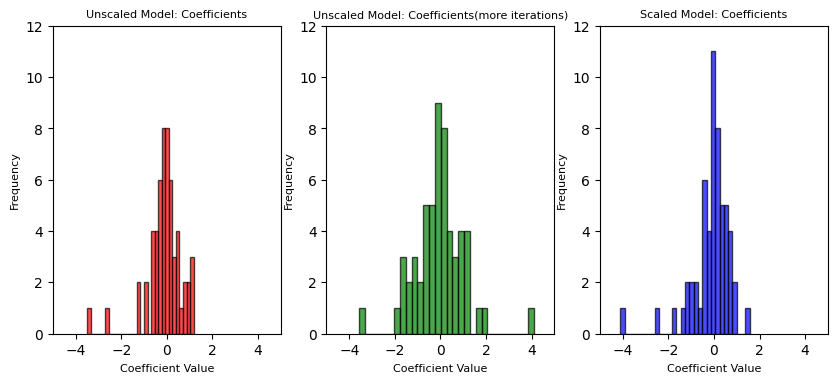

In [15]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(10, 4))

unscaled_coef = np.reshape(classifier.coef_,-1)
unscaled_more_iter_coef = np.reshape(classifier_more_iter.coef_,-1)
scaled_coef = np.reshape(classifier_scaled.coef_,-1)

ax1.hist(unscaled_coef, bins=30, color='red', edgecolor='black', alpha=0.7)
ax1.set_title('Unscaled Model: Coefficients',fontsize = 8)
ax1.set_xlabel('Coefficient Value',fontsize = 8)
ax1.set_ylabel('Frequency',fontsize = 8)

ax1.set_xlim(xmin = -5, xmax = 5)
ax1.set_ylim(ymax = 12)

ax2.hist(unscaled_more_iter_coef, bins=30, color='green', edgecolor='black', alpha=0.7)
ax2.set_title('Unscaled Model: Coefficients(more iterations)',fontsize = 8)
ax2.set_xlabel('Coefficient Value',fontsize = 8)
ax2.set_ylabel('Frequency',fontsize = 8)

ax2.set_xlim(xmin = -5, xmax = 5)
ax2.set_ylim(ymax = 12)

ax3.hist(scaled_coef, bins=30, color='blue', edgecolor='black', alpha=0.7)
ax3.set_title('Scaled Model: Coefficients',fontsize = 8)
ax3.set_xlabel('Coefficient Value',fontsize = 8)
ax3.set_ylabel('Frequency',fontsize = 8)

ax3.set_xlim(xmin = -5, xmax = 5)
ax3.set_ylim(ymax = 12)

plt.show()

##### Per Feature Coefficient Change

In [19]:
feature_names = df.drop(columns='class').columns
comp = pd.DataFrame({'unscaled': classifier_more_iter.coef_[0],
                     'scaled':   classifier_scaled.coef_[0]}, index=feature_names)
comp['diff'] = comp.scaled - comp.unscaled
comp['predicted'] = comp.unscaled * X_train.std(axis=0)
comp['gap'] = comp.scaled - comp.predicted
print(comp.reindex(comp['diff'].abs().sort_values(ascending=False).index).head(10))


                            unscaled    scaled      diff  predicted       gap
char_freq_%24               4.105465  1.568022 -2.537443   1.042810  0.525212
word_freq_remove            1.938318  0.793511 -1.144807   0.739088  0.054423
word_freq_000               1.735294  0.683281 -1.052013   0.618605  0.064676
capital_run_length_longest  0.008079  0.907000  0.898921   1.090066 -0.183066
word_freq_conference       -1.614590 -0.723025  0.891565  -0.402980 -0.320046
char_freq_%3B              -1.112903 -0.338435  0.774468  -0.296708 -0.041728
char_freq_%23               1.240937  0.478677 -0.762260   0.277293  0.201384
word_freq_hp               -1.684642 -2.417345 -0.732703  -2.809333  0.391988
word_freq_addresses         1.089661  0.465599 -0.624062   0.277224  0.188376
word_freq_technology        0.983227  0.401567 -0.581660   0.407593 -0.006025


##### Conclusions

  * Not only is the scaled model faster, 96× fewer iterations, but its actually a fully fitted correct model.
  * The unscaled model doesn't just take longer, it silently returns a wrong, underfit model, as seen in the results table: absence of a train set advantage. In other words a model underfit on the train set wont favor it.
  * Scaling didn't meaningfully change accuracy (+0.005 on test, within seed noise). What it changed is whether the model is fitted at all at default settings: 32 iterations versus 3,074, converged versus silently truncated.
  * Scaling is not a change of units when a penalty is present. Pure rescaling requires scaled = unscaled × σ exactly; the gap reaches 0.53 on `char_freq_$`, a third of that coefficient. And the direction is informative — `capital_run_length_longest` (large range) came out smaller than predicted, `char_freq_$` (small range) larger, the penalty had been sparing the first and suppressing the second. This is because the L2 penalty, LogisticRegression's default, charges by raw coefficient magnitude, so it is applied unequally across features measured in different units.




### Fitting the Model Across Different Orders of Magnitude

In [17]:
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score
Cs = np.logspace(-4, 4, 9)
CV = []
train_score = []
w = []
for C_val in Cs:
  pipe = make_pipeline(StandardScaler(), LogisticRegression(C = C_val))
  pipe.fit(X_train, y_train)
  print(f'C value: {C_val}\nnumber of iterations: {pipe.named_steps['logisticregression'].n_iter_ }')
  print(f'CV: {cross_val_score(pipe, X_train, y_train, cv=5)}')
  print(f'train score: {pipe.score(X_train, y_train)}')
  print('----------------------------------------------------------------------\n')

  CV.append(cross_val_score(pipe, X_train, y_train, cv=5))
  train_score.append(pipe.score(X_train, y_train))
  w.append(np.linalg.norm(pipe.named_steps['logisticregression'].coef_))

C value: 0.0001
number of iterations: [8]
CV: [0.70108696 0.72418478 0.70516304 0.70244565 0.69429348]
train score: 0.73125
----------------------------------------------------------------------

C value: 0.001
number of iterations: [8]
CV: [0.875      0.8763587  0.86277174 0.86548913 0.8736413 ]
train score: 0.8790760869565217
----------------------------------------------------------------------

C value: 0.01
number of iterations: [10]
CV: [0.91983696 0.91032609 0.91711957 0.90081522 0.91304348]
train score: 0.9171195652173914
----------------------------------------------------------------------

C value: 0.1
number of iterations: [19]
CV: [0.92798913 0.93070652 0.91440217 0.91576087 0.92663043]
train score: 0.9279891304347826
----------------------------------------------------------------------

C value: 1.0
number of iterations: [32]
CV: [0.93478261 0.92934783 0.92119565 0.92934783 0.93342391]
train score: 0.9342391304347826
------------------------------------------------------

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


CV: [0.92798913 0.93342391 0.92391304 0.9388587  0.94021739]
train score: 0.9375
----------------------------------------------------------------------



/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C value: 1000.0
number of iterations: [75]


...

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

C value: 10000.0
number of iterations: [78]


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


CV: [0.92798913 0.93342391 0.92255435 0.9388587  0.9388587 ]
train score: 0.9380434782608695
----------------------------------------------------------------------



/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


#### Plotting Each C's training score, cross-validated score, and ∥𝑤∥.


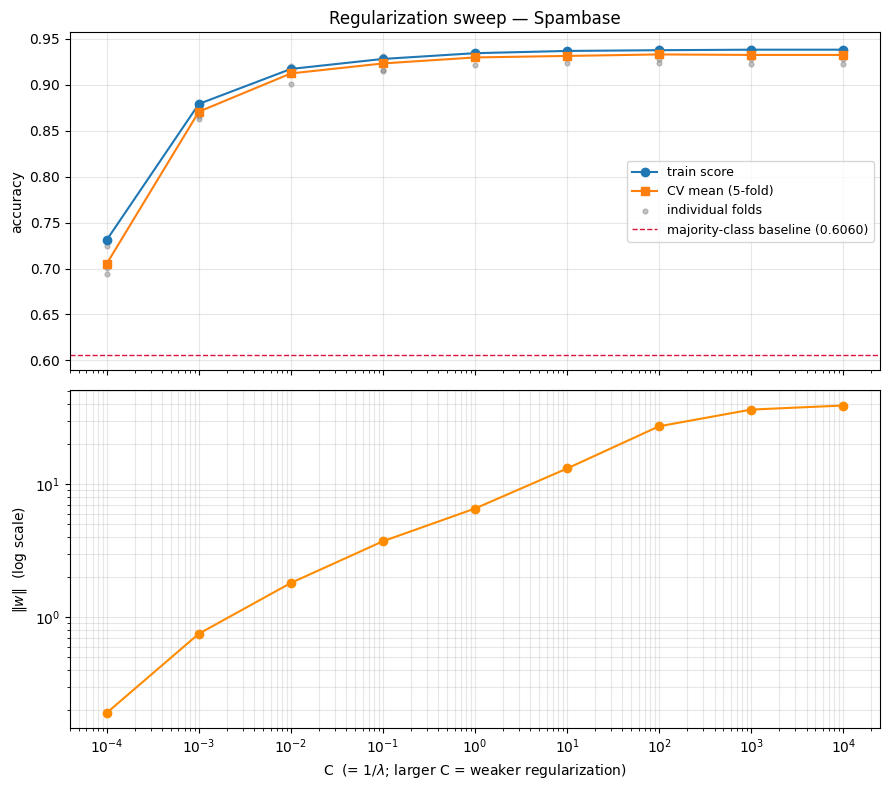

In [18]:
CV_arr  = np.array(CV)          # shape (9, 5)
cv_mean = CV_arr.mean(axis=1)
cv_std  = CV_arr.std(axis=1)
BASELINE = 0.6060

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(9, 8))

# --- top: accuracies ---
ax1.plot(Cs, train_score, 'o-', label='train score')
ax1.plot(Cs, cv_mean, 's-', label='CV mean (5-fold)')
ax1.scatter(np.repeat(Cs, 5), CV_arr.ravel(), s=12, alpha=.45,
            c='gray', label='individual folds', zorder=1)
ax1.axhline(BASELINE, ls='--', c='crimson', lw=1,
            label=f'majority-class baseline ({BASELINE:.4f})')
ax1.set_ylabel('accuracy')
ax1.set_title('Regularization sweep — Spambase')
ax1.legend(loc='center right', fontsize=9)
ax1.grid(alpha=.3)

# --- bottom: ‖w‖ ---
ax2.plot(Cs, w, 'o-', color='darkorange')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel(r'C  (= 1/$\lambda$; larger C = weaker regularization)')
ax2.set_ylabel(r'$\|w\|$  (log scale)')
ax2.grid(alpha=.3, which='both')

plt.tight_layout()
plt.show()

#### Conclusions

* Smaller C values correspond to smaller coefficients.
* More magnitude leads to more accuracy - up until some point, in this case up until C = 1. Past it ‖w‖ goes 6.55 → 39.01 (6×) and buys +0.0033 CV.
* C = 100 was the highest scoring C (0.9329). Compared with 0.9313 (C=10) and 0.9323 (C=1e3). Differences: 0.0016, 0.0005 respectively, against a fold-to-fold std of 0.0070 — the gaps between candidates are 4-14× smaller than the noise in measuring any one of them, so it's just noise. The model doesn't get any better past C = 1.
* I would choose C=1 even though the technically highest scoring is C=100, because the model doesn't get meaningfully better after C=1, the reason C=100 scores higher is pure luck, a different random seed will almost definitely change that. Therefore, we choose the simplest model, an application of Occam's Razor.
* The formal version of this is the one-standard-error rule: pick the most regularized model within one standard error of the best. Here it's ambiguous — SE = 0.0070/√5 = 0.0031, so the threshold is 0.9298 and C=1 misses it by 0.0002 (the rule picks C=10). Using the raw std instead, the threshold is 0.9259 and C=1 qualifies.

### Fitting the Model with no Regularization

In [22]:
pipe_nopen = make_pipeline(StandardScaler(),LogisticRegression(penalty=None, max_iter=1000))
pipe_nopen_more_iter = make_pipeline(StandardScaler(),LogisticRegression(penalty=None, max_iter=100000))
for name, p in [('max_iter=1e3', pipe_nopen), ('max_iter=1e5', pipe_nopen_more_iter)]:
    p.fit(X_train, y_train)
    lr = p.named_steps['logisticregression']
    print(f'{name}: n_iter_={lr.n_iter_}  ‖w‖={np.linalg.norm(lr.coef_):.4f}  '
          f'train={p.score(X_train, y_train):.4f}')

max_iter=1e3: n_iter_=[77]  ‖w‖=38.9537  train=0.9380
max_iter=1e5: n_iter_=[77]  ‖w‖=38.9537  train=0.9380


#### Conclusions

* Whether unregularized logistic regression converges is a property of the data, not the algorithm. Separable → no finite solution, weights diverge. Overlapping → finite MLE, converges normally. This is demonstrated below:

* From DeepLearning.Ai - ML Spec - Supervised Machine Learning: Regression and Classification course W3 Lab06's toy data(Measured Previously):  
    * ‖w‖ 3.10 → 16.01 from 1k to 1M iterations, cost still falling.

* From this notebook on Spambase dataset:
  * n_iter_ 77 and ‖w‖ 38.9537 at both max_iter=1e3 and 1e5 — identical to four decimals.